In [1]:
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import SAGEConv, to_hetero, HeteroConv
from torch_geometric.data import HeteroData
from torch_geometric.transforms import RandomLinkSplit
from sklearn.metrics import roc_auc_score # Common metric for link prediction
import matplotlib.pyplot as plt

import os
import numpy as np
import json

from utils.hake_dataset import invert_nested_dict

/home/mai/miniconda3/envs/pyg-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from torch_geometric import seed_everything

seed_everything(4444)

In [3]:
DATA_PATH = './data'

# folder to save entity id mapping
ID_MAPPING = os.path.join(DATA_PATH, 'entity_id_map')
os.makedirs(ID_MAPPING, exist_ok=True)

# folder to save edge index
EDGE_INDEX = os.path.join(DATA_PATH, 'edge_index')
os.makedirs(EDGE_INDEX, exist_ok=True)

# folder to save graph data
GRAPH_DATA = os.path.join(DATA_PATH, 'graph_data')
os.makedirs(GRAPH_DATA, exist_ok=True)

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 0. Load data

## 0.1. Add reverse edge types

In [5]:
# load data
data = torch.load(os.path.join(GRAPH_DATA, 'yfinance_kge_full.pt'))

# Load the map (assuming invert_nested_dict is defined)
with open(os.path.join(ID_MAPPING, 'global_id.json')) as f:
    raw_global2local = invert_nested_dict(json.load(f)) # Use a temporary name

# 2. Convert ALL keys and values to integers (CRITICAL STEP)
global2local = {}
for ntype, g_to_l_map in raw_global2local.items():
    # Convert global ID keys (strings) and local ID values (strings) to integers
    global2local[ntype] = {
        int(global_id): int(local_id) 
        for global_id, local_id in g_to_l_map.items()
    }

EDGE_TYPES_ORIGINAL = [
    ('company', 'has_symbol', 'stock_symbol'),
    ('company', 'belongs_to', 'industry'),
    ('industry', 'is_part_of', 'sector'),
    ('institution', 'holds', 'stock_symbol'),
    ('fund', 'holds', 'stock_symbol'),
    ('fund', 'has_symbol', 'fund_symbol'),
]

FINAL_EDGE_TYPES = []
device = data.edge_index_dict[EDGE_TYPES_ORIGINAL[0]].device # Get device from an existing tensor

print("Starting localization of edge indices and creating inverse relations...")

for src, rel, dst in EDGE_TYPES_ORIGINAL:
    
    original_edge_type = (src, rel, dst)
    
    # 1. Check and Retrieve Data
    if original_edge_type not in data.edge_types:
        print(f"Warning: Skipping {original_edge_type} - not found in data.")
        continue
        
    # Get the original index tensor (assumed to hold global IDs).
    # Move to CPU for efficient dictionary lookup, then back to device later.
    original_index_global = data[original_edge_type].edge_index.cpu() 
    
    # Get the mapping dictionaries for source and destination types
    src_map = global2local[src]
    dst_map = global2local[dst]

    # Create lists to hold the new, localized indices
    new_src_indices = []
    new_dst_indices = []
    
    # Map the global IDs to local IDs
    for i in range(original_index_global.size(1)):
        global_src_id = original_index_global[0, i].item()
        global_dst_id = original_index_global[1, i].item()
        
        try:
            # Look up the new local IDs using the nested map structure
            new_src_indices.append(src_map[global_src_id])
            new_dst_indices.append(dst_map[global_dst_id])
        except KeyError as e:
            # This handles cases where an edge points to a node ID that 
            # might not be present in your loaded features/map (e.g., filtered nodes).
            # We skip the problematic edge.
            # print(f"KeyError: Missing Global ID {e} in map for edge type {original_edge_type}. Skipping edge.")
            continue


    # 2. Overwrite the Original Edge with the localized index
    new_index_local = torch.stack([
        torch.tensor(new_src_indices, dtype=torch.long),
        torch.tensor(new_dst_indices, dtype=torch.long)
    ]).to(device)

    data[original_edge_type].edge_index = new_index_local
    FINAL_EDGE_TYPES.append(original_edge_type)

    
    # 3. Create the Inverse Edge
    inverse_rel = f'rev_{rel}'
    inverse_edge_type = (dst, inverse_rel, src)
    
    # The inverse index is the new_index_local flipped!
    data[inverse_edge_type].edge_index = new_index_local.flip(0)
    FINAL_EDGE_TYPES.append(inverse_edge_type)
    
print(f"✅ Localization complete. Total edge types (Original + Inverse): {len(FINAL_EDGE_TYPES)}")

/tmp/ipykernel_42679/884776007.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(os.path.join(GRAPH_DATA, 'yfinance_kge_full.pt'))


Starting localization of edge indices and creating inverse relations...
✅ Localization complete. Total edge types (Original + Inverse): 12


In [6]:
data

HeteroData(
  company={ x=[4164, 70] },
  fund_symbol={ x=[6340, 61] },
  sector={ x=[13, 39] },
  industry={ x=[146, 41] },
  stock_symbol={ x=[4607, 32] },
  institution={ x=[2669, 32] },
  fund={ x=[2222, 32] },
  (company, has_symbol, stock_symbol)={ edge_index=[2, 4508] },
  (company, belongs_to, industry)={ edge_index=[2, 3992] },
  (industry, is_part_of, sector)={ edge_index=[2, 144] },
  (institution, holds, stock_symbol)={ edge_index=[2, 39512] },
  (fund, holds, stock_symbol)={ edge_index=[2, 37098] },
  (fund, has_symbol, fund_symbol)={ edge_index=[2, 6851] },
  (stock_symbol, rev_has_symbol, company)={ edge_index=[2, 4508] },
  (industry, rev_belongs_to, company)={ edge_index=[2, 3992] },
  (sector, rev_is_part_of, industry)={ edge_index=[2, 144] },
  (stock_symbol, rev_holds, institution)={ edge_index=[2, 39512] },
  (stock_symbol, rev_holds, fund)={ edge_index=[2, 37098] },
  (fund_symbol, rev_has_symbol, fund)={ edge_index=[2, 6851] }
)

## 0.2. Split the features
Split the previously concatenated feature tensors back into its components:
* The original features engineered from the yahoo finance API stays in `.x`
* The HAKE embeddings are moved to a new attribute `.hake_embeds`. These will be trainable with an `nn.Embedding` layer

In [7]:
# data.node_types

In [8]:
HAKE_EMBED_DIM = 32
# Define a minimal constant dimension for nodes that inherently lack fixed features
DEFAULT_FIXED_DIM = 1 
DEFAULT_FIXED_VALUE = 1.0

for ntype in data.node_types:
    if hasattr(data[ntype], 'x') and data[ntype].x is not None:
        full_tensor = data[ntype].x
        N_nodes = full_tensor.size(0)
        data[ntype].num_nodes = N_nodes
        # number of fixed features
        D_fixed = full_tensor.size(1) - HAKE_EMBED_DIM

    # --- 1. Store HAKE embeddings (last HAKE_EMBED_DIM columns) ---
    data[ntype].hake_embeds = full_tensor[:, -HAKE_EMBED_DIM:].clone().detach()

    # --- 2. Create the fixed_x tensor based on D_fixed ---
    if D_fixed > 0:
        # Split the tensor as usual
        data[ntype].fixed_x = full_tensor[:, :D_fixed].clone().detach()
        print(f"  - {ntype}: Split features. D_fixed={D_fixed}, D_hake={HAKE_EMBED_DIM}.")

    else:
        # No fixed features 
        # Create a minimal constant tensor for fixed_x to satisfy the GNN architecture.
        data[ntype].fixed_x = torch.full((N_nodes, DEFAULT_FIXED_DIM), 
                                         DEFAULT_FIXED_VALUE, 
                                         dtype=torch.float, 
                                         device=device)
        print(f"  - {ntype}: Only HAKE found. Assigned default fixed_x (D={DEFAULT_FIXED_DIM}).")

    # --- 3. Create the index tensor (applies to all cases) ---
    data[ntype].idx = torch.arange(N_nodes, dtype=torch.long, device=device)
    
    # Remove the original concatenated .x to clean up the input
    del data[ntype].x

print("Data preparation complete: features split into .fixed_x and .hake_embeds.")

  - company: Split features. D_fixed=38, D_hake=32.
  - fund_symbol: Split features. D_fixed=29, D_hake=32.
  - sector: Split features. D_fixed=7, D_hake=32.
  - industry: Split features. D_fixed=9, D_hake=32.
  - stock_symbol: Only HAKE found. Assigned default fixed_x (D=1).
  - institution: Only HAKE found. Assigned default fixed_x (D=1).
  - fund: Only HAKE found. Assigned default fixed_x (D=1).
Data preparation complete: features split into .fixed_x and .hake_embeds.


In [9]:
data

HeteroData(
  company={
    num_nodes=4164,
    hake_embeds=[4164, 32],
    fixed_x=[4164, 38],
    idx=[4164],
  },
  fund_symbol={
    num_nodes=6340,
    hake_embeds=[6340, 32],
    fixed_x=[6340, 29],
    idx=[6340],
  },
  sector={
    num_nodes=13,
    hake_embeds=[13, 32],
    fixed_x=[13, 7],
    idx=[13],
  },
  industry={
    num_nodes=146,
    hake_embeds=[146, 32],
    fixed_x=[146, 9],
    idx=[146],
  },
  stock_symbol={
    num_nodes=4607,
    hake_embeds=[4607, 32],
    fixed_x=[4607, 1],
    idx=[4607],
  },
  institution={
    num_nodes=2669,
    hake_embeds=[2669, 32],
    fixed_x=[2669, 1],
    idx=[2669],
  },
  fund={
    num_nodes=2222,
    hake_embeds=[2222, 32],
    fixed_x=[2222, 1],
    idx=[2222],
  },
  (company, has_symbol, stock_symbol)={ edge_index=[2, 4508] },
  (company, belongs_to, industry)={ edge_index=[2, 3992] },
  (industry, is_part_of, sector)={ edge_index=[2, 144] },
  (institution, holds, stock_symbol)={ edge_index=[2, 39512] },
  (fund, holds

# 1. Define Feature Manager module
Distinguish between fixed features and trainable embeddings 

In [10]:
class FeatureManager(nn.Module):
    def __init__(self, data):
        super().__init__()
        
        self.embedding_layers = nn.ModuleDict()
        self.fixed_features = nn.ParameterDict()
        self.node_types = data.node_types
        
        for ntype in self.node_types:
            
            # --- Trainable HAKE Embeddings (nn.Embedding) ---
            if hasattr(data[ntype], 'hake_embeds'):
                hake_tensor = data[ntype].hake_embeds
                N_nodes, D_hake = hake_tensor.shape
                
                # Create trainable nn.Embedding layer, initialized with HAKE weights
                embed_layer = nn.Embedding(N_nodes, D_hake)
                embed_layer.weight.data.copy_(hake_tensor.to(dtype=torch.float))
                self.embedding_layers[ntype] = embed_layer

            # --- Fixed Original Features (nn.Parameter(requires_grad=False)) ---
            if hasattr(data[ntype], 'fixed_x'):
                fixed_tensor = data[ntype].fixed_x
                # Wrap as fixed Parameter, requires_grad=False is CRITICAL here
                fixed_param = nn.Parameter(fixed_tensor.to(dtype=torch.float), requires_grad=False)
                self.fixed_features[ntype] = fixed_param
                
    def forward(self, idx_dict, device):
        """Combines and returns the final feature dictionary for the GNN."""
        x_dict = {}
        for ntype in self.node_types:
            
            fixed_x = self.fixed_features.get(ntype)
            
            # 1. Get trainable HAKE embeddings
            if ntype in self.embedding_layers:
                hake_indices = idx_dict[ntype].to(device)
                trainable_hake_x = self.embedding_layers[ntype](hake_indices)
                
                # 2. Concatenate
                if fixed_x is not None:
                    x_dict[ntype] = torch.cat([fixed_x, trainable_hake_x], dim=-1)
                else:
                    x_dict[ntype] = trainable_hake_x
            
            elif fixed_x is not None:
                 # Case where only fixed features exist (e.g., if D_hake=0 for a node type)
                 x_dict[ntype] = fixed_x
                 
        return x_dict

# 2. Define GNN Encoder
Takes in the feature dictionary and edge index to train the model

In [11]:
class GNNEncoder(torch.nn.Module):
    def __init__(self, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv((-1, -1), out_channels)
        self.act = torch.nn.ReLU()
        self.dropout = torch.nn.Dropout(p=dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.act(x)
        x = self.dropout(x)
        return x

# 3. Define Link predictor (decoder)

In [12]:
class EdgeDecoder(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, z_src, z_dst, edge_label_index):
        # Retrieve the embeddings for the edges' source and destination nodes
        src, dst = edge_label_index
        z_src = z_src[src]
        z_dst = z_dst[dst]
        
        # Calculate the score (e.g., dot product)
        score = torch.sum(z_src * z_dst, dim=-1)
        return score

# 4. Training & eval functions

In [13]:
def split_data(data, num_val, num_test, neg_sampling_ratio, is_undirected, edge_types, rev_edge_types):
    transform = RandomLinkSplit(
        num_val=num_val,
        num_test=num_test,
        neg_sampling_ratio=neg_sampling_ratio,
        is_undirected=is_undirected,
        edge_types=edge_types,
        rev_edge_types=rev_edge_types,
    )
    train_data, val_data, test_data = transform(data)
    return train_data, val_data, test_data

In [14]:
def get_encoder_inputs(data_split, device):
    """
    Prepares the index dictionary required by the FeatureManager.
    
    Args:
        data_split (HeteroData): train_data, val_data, or test_data.
        device (torch.device): The device the tensors should be on.
    
    Returns:
        tuple: (edge_index_dict, idx_dict)
    """
    idx_dict = {}
    
    # Iterate over all node types in the data split
    for ntype in data_split.node_types:
        # Get the index tensor for the FeatureManager's nn.Embedding lookup
        # This attribute (idx) was created during your data preparation step.
        if hasattr(data_split[ntype], 'idx'):
            idx_dict[ntype] = data_split[ntype].idx.to(device)
            
    # Return the graph structure (edge indices) and the node indices
    return data_split.edge_index_dict, idx_dict

In [15]:
def train(train_data, feature_manager, hetero_model, predictor, optimizer, edge_types, criterion, device):
    """
    Performs a single training epoch using the FeatureManager for feature generation.
    """
    feature_manager.train()
    hetero_model.train()
    predictor.train()
    optimizer.zero_grad()
    
    # 1. Prepare inputs (get the graph structure and the indices)
    edge_index_dict, idx_dict = get_encoder_inputs(train_data, device)
    
    # 2. Feature Generation (HAKE lookup and concatenation with fixed features)
    # x_dict is the final combined feature dictionary ready for the GNN
    x_dict = feature_manager(idx_dict, device) 
    
    # 3. GNN Forward Pass
    z_dict = hetero_model(x_dict, edge_index_dict)
    
    total_loss = 0
    
    # 4. Link Prediction and Loss Calculation (using forward EDGE_TYPES only)
    for edge_type in edge_types:
        
        edge_label_index = train_data[edge_type].edge_label_index.to(device)
        edge_labels = train_data[edge_type].edge_label.float().to(device)

        src_type, _, dst_type = edge_type
        
        scores = predictor(
            z_dict[src_type], 
            z_dict[dst_type], 
            edge_label_index
        )

        loss = criterion(scores, edge_labels)
        total_loss += loss
        
    # 5. Backpropagation
    total_loss.backward()
    
    optimizer.step()
    
    return total_loss.item()

In [16]:
@torch.no_grad()
def evaluate(data_split, feature_manager, hetero_model, predictor, edge_types, criterion, device):
    """
    Evaluates the model and returns the total loss and AUC score.
    """
    feature_manager.eval()
    hetero_model.eval()
    predictor.eval()

    # 1. Prepare inputs (get the graph structure and the indices)
    edge_index_dict, idx_dict = get_encoder_inputs(data_split, device)
    
    # 2. Feature Generation
    x_dict = feature_manager(idx_dict, device)
    
    # 3. GNN Forward Pass
    z_dict = hetero_model(x_dict, edge_index_dict)
    
    total_loss = 0
    all_scores = []
    all_labels = []

    # 4. Link Prediction and Metrics Calculation
    for edge_type in edge_types:
        
        edge_label_index = data_split[edge_type].edge_label_index.to(device)
        edge_labels = data_split[edge_type].edge_label.float().to(device)
        
        src_type, _, dst_type = edge_type
        
        scores_logits = predictor(
            z_dict[src_type], 
            z_dict[dst_type], 
            edge_label_index
        )
        
        # Calculate loss
        loss = criterion(scores_logits, edge_labels)
        total_loss += loss.item()

        # Collect scores and labels for AUC
        scores_prob = torch.sigmoid(scores_logits)
        all_scores.append(scores_prob.cpu())
        all_labels.append(edge_labels.cpu())

    # 5. Calculate overall AUC
    try:
        y_score = torch.cat(all_scores).view(-1).numpy()
        y_true = torch.cat(all_labels).view(-1).numpy()

        if len(torch.unique(torch.tensor(y_true))) > 1:
            from sklearn.metrics import roc_auc_score
            auc = roc_auc_score(y_true, y_score)
        else:
            auc = 0.5 
            
    except ValueError:
        auc = 0.5

    return total_loss, auc

In [17]:
import matplotlib.pyplot as plt

def plot_metrics(train_losses, val_losses, val_aucs):
    """
    Plots the training loss, validation loss, and validation AUC over epochs.

    Args:
        train_losses (list): List of training loss values per epoch.
        val_losses (list): List of validation loss values per epoch.
        val_aucs (list): List of validation AUC scores per epoch.
    """
    
    # Calculate the number of epochs from the length of the logged lists
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(12, 5))

    # --- Plot 1: Loss Curve (Train vs. Validation) ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss', linestyle='-')
    plt.plot(epochs, val_losses, label='Validation Loss', linestyle='--')
    
    plt.title('Loss Curve Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (BCE)')
    plt.legend()
    plt.grid(True, alpha=0.5)

    # --- Plot 2: AUC Curve (Validation Metric) ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_aucs, label='Train AUC', ls='-')
    plt.plot(epochs, val_aucs, label='Validation AUC', ls='-')
    
    plt.title('AUC Score')
    plt.xlabel('Epoch')
    plt.ylabel('AUC Score')
    plt.ylim(0.0, 1.0) # AUC scores are between 0 and 1
    plt.legend()
    plt.grid(True, alpha=0.5)

    plt.tight_layout()
    plt.show()

# 5. Execution

## 5.1. Link prediction between funds and stock symbols

In [18]:
EPOCHS = 2000
# HIDDEN_CHANNELS = 256
OUT_CHANNELS = 32
LEARNING_RATE = 0.0001

NODE_TYPES = ['company', 'stock_symbol', 'industry', 'sector', 
              'institution', 'fund', 'fund_symbol']

In [19]:
EDGE_TYPES = [
    # ('institution', 'holds', 'stock_symbol'),
    ('fund', 'holds', 'stock_symbol'),
]

REV_EDGE_TYPES = [
    # ('stock_symbol', 'rev_holds', 'institution'),
    ('stock_symbol', 'rev_holds', 'fund'),
]

EDGE_TYPES_ALL = EDGE_TYPES + REV_EDGE_TYPES

In [20]:
# data split
data = data.to(device)

train_data, val_data, test_data = split_data(data, 
                                             num_val=0.2, 
                                             num_test=0.2, 
                                             neg_sampling_ratio=1.0, 
                                             is_undirected=False, 
                                             edge_types=EDGE_TYPES,
                                             rev_edge_types=REV_EDGE_TYPES,
                                            )

In [21]:
# Prepare the metadata for model initialization
# 1. Extract Shape Information
hake_shapes = {}
fixed_x_shapes = {}
for ntype in data.node_types:
    if hasattr(data[ntype], 'hake_embeds'):
        N, D_hake = data[ntype].hake_embeds.shape
        hake_shapes[ntype] = (N, D_hake)
    if hasattr(data[ntype], 'fixed_x'):
        D_fixed = data[ntype].fixed_x.shape[1]
        fixed_x_shapes[ntype] = D_fixed

# 2. Get the Metadata (contains all node and edge types)
metadata = data.metadata()

In [22]:
# --- 1. Initialize the Feature Manager (Handles trainable HAKE embeddings) ---
# NOTE: The FeatureManager's __init__ method ALREADY loads the HAKE vectors 
# and fixed features into its internal layers and parameters.
feature_manager = FeatureManager(data).to(device)

# --- REMOVE THIS LINE: ---
# feature_manager.load_initial_weights(data) 
# -------------------------

# --- 2. Initialize the GNN Encoder (Homogeneous base model) ---
gnn_encoder = GNNEncoder(OUT_CHANNELS).to(device)

# --- 3. Wrap the GNN Encoder for Heterogeneous processing (The 'Model') ---
# Assuming metadata is defined from data.metadata()
metadata = data.metadata()
hetero_model = to_hetero(gnn_encoder, metadata, aggr='sum').to(device)

# --- 4. Initialize the Decoder ---
predictor = EdgeDecoder().to(device)

# --- 5. Optimizer Setup (CRITICAL: Must include all trainable parameters) ---
optimizer = torch.optim.Adam(
    list(feature_manager.parameters()) + list(hetero_model.parameters()) + list(predictor.parameters()), 
    lr=LEARNING_RATE
)

In [23]:
# training loop
train_losses = []
train_aucs = []
val_losses = []
val_aucs = []

criterion = torch.nn.BCEWithLogitsLoss()
print("\nStarting training loop...")
for epoch in range(1, EPOCHS + 1):
    
    # Train function modified to include the feature_manager
    train_loss = train(
        train_data, 
        feature_manager,  # <-- ADDED
        hetero_model, 
        predictor, 
        optimizer, 
        EDGE_TYPES, 
        criterion, 
        device
    )
    
    # Evaluation function calls modified to include the feature_manager
    _, train_auc = evaluate(
        train_data, 
        feature_manager,  # <-- ADDED
        hetero_model, 
        predictor, 
        EDGE_TYPES, 
        criterion, 
        device
    )
    val_loss, val_auc = evaluate(
        val_data, 
        feature_manager,  # <-- ADDED
        hetero_model, 
        predictor, 
        EDGE_TYPES, 
        criterion, 
        device
    )

    # Log metrics
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch:02d}/{EPOCHS}, Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}, Val Loss: {val_loss:.4f}, Val AUC: {val_auc:.4f}")

# --- Final Testing ---
test_loss, test_auc = evaluate(
    test_data, 
    feature_manager,  # <-- ADDED
    hetero_model, 
    predictor, 
    EDGE_TYPES, 
    criterion, 
    device
)
print(f"\n✅ Training Complete. Test Loss: {test_loss:.4f}, Test AUC: {test_auc:.4f}")


Starting training loop...
Epoch: 10/2000, Train Loss: 1.2613, Train AUC: 0.5480, Val Loss: 1.1441, Val AUC: 0.5440
Epoch: 20/2000, Train Loss: 1.2107, Train AUC: 0.5510, Val Loss: 1.1045, Val AUC: 0.5459
Epoch: 30/2000, Train Loss: 1.1834, Train AUC: 0.5541, Val Loss: 1.0680, Val AUC: 0.5478
Epoch: 40/2000, Train Loss: 1.1448, Train AUC: 0.5573, Val Loss: 1.0348, Val AUC: 0.5498
Epoch: 50/2000, Train Loss: 1.0902, Train AUC: 0.5605, Val Loss: 1.0045, Val AUC: 0.5519
Epoch: 60/2000, Train Loss: 1.0677, Train AUC: 0.5636, Val Loss: 0.9769, Val AUC: 0.5539
Epoch: 70/2000, Train Loss: 1.0344, Train AUC: 0.5669, Val Loss: 0.9518, Val AUC: 0.5559
Epoch: 80/2000, Train Loss: 1.0187, Train AUC: 0.5701, Val Loss: 0.9289, Val AUC: 0.5579
Epoch: 90/2000, Train Loss: 0.9774, Train AUC: 0.5734, Val Loss: 0.9081, Val AUC: 0.5600
Epoch: 100/2000, Train Loss: 0.9692, Train AUC: 0.5768, Val Loss: 0.8890, Val AUC: 0.5622
Epoch: 110/2000, Train Loss: 0.9367, Train AUC: 0.5802, Val Loss: 0.8717, Val AUC:

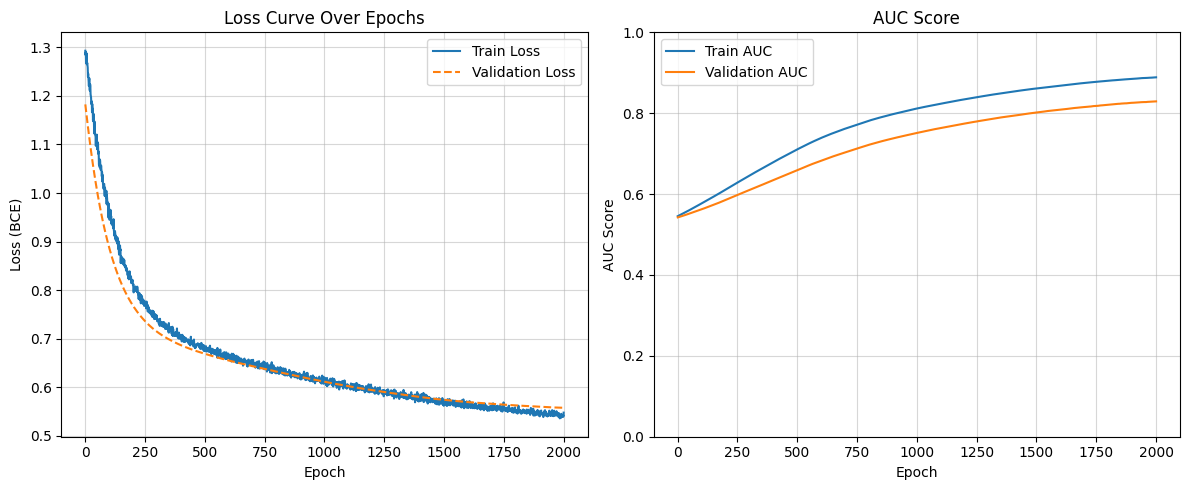

In [24]:
plot_metrics(train_losses, val_losses, val_aucs)

## 5.2. Link prediction between institutions and stock symbols

In [25]:
EPOCHS = 3000
# HIDDEN_CHANNELS = 256
OUT_CHANNELS = 32
LEARNING_RATE = 0.0001

NODE_TYPES = ['company', 'stock_symbol', 'industry', 'sector', 
              'institution', 'fund', 'fund_symbol']

In [26]:
EDGE_TYPES = [
    ('institution', 'holds', 'stock_symbol'),
    # ('fund', 'holds', 'stock_symbol'),
]

REV_EDGE_TYPES = [
    ('stock_symbol', 'rev_holds', 'institution'),
    # ('stock_symbol', 'rev_holds', 'fund'),
]

EDGE_TYPES_ALL = EDGE_TYPES + REV_EDGE_TYPES

In [27]:
# data split
data = data.to(device)

train_data, val_data, test_data = split_data(data, 
                                             num_val=0.2, 
                                             num_test=0.2, 
                                             neg_sampling_ratio=1.0, 
                                             is_undirected=False, 
                                             edge_types=EDGE_TYPES,
                                             rev_edge_types=REV_EDGE_TYPES,
                                            )

In [28]:
# Prepare the metadata for model initialization
# 1. Extract Shape Information
hake_shapes = {}
fixed_x_shapes = {}
for ntype in data.node_types:
    if hasattr(data[ntype], 'hake_embeds'):
        N, D_hake = data[ntype].hake_embeds.shape
        hake_shapes[ntype] = (N, D_hake)
    if hasattr(data[ntype], 'fixed_x'):
        D_fixed = data[ntype].fixed_x.shape[1]
        fixed_x_shapes[ntype] = D_fixed

# 2. Get the Metadata (contains all node and edge types)
metadata = data.metadata()

In [29]:
# --- 1. Initialize the Feature Manager (Handles trainable HAKE embeddings) ---
# NOTE: The FeatureManager's __init__ method ALREADY loads the HAKE vectors 
# and fixed features into its internal layers and parameters.
feature_manager = FeatureManager(data).to(device)

# --- REMOVE THIS LINE: ---
# feature_manager.load_initial_weights(data) 
# -------------------------

# --- 2. Initialize the GNN Encoder (Homogeneous base model) ---
gnn_encoder = GNNEncoder(OUT_CHANNELS).to(device)

# --- 3. Wrap the GNN Encoder for Heterogeneous processing (The 'Model') ---
# Assuming metadata is defined from data.metadata()
metadata = data.metadata()
hetero_model = to_hetero(gnn_encoder, metadata, aggr='sum').to(device)

# --- 4. Initialize the Decoder ---
predictor = EdgeDecoder().to(device)

# --- 5. Optimizer Setup (CRITICAL: Must include all trainable parameters) ---
optimizer = torch.optim.Adam(
    list(feature_manager.parameters()) + list(hetero_model.parameters()) + list(predictor.parameters()), 
    lr=LEARNING_RATE
)

In [30]:
# training loop
train_losses = []
train_aucs = []
val_losses = []
val_aucs = []

criterion = torch.nn.BCEWithLogitsLoss()
print("\nStarting training loop...")
for epoch in range(1, EPOCHS + 1):
    
    # Train function modified to include the feature_manager
    train_loss = train(
        train_data, 
        feature_manager,  # <-- ADDED
        hetero_model, 
        predictor, 
        optimizer, 
        EDGE_TYPES, 
        criterion, 
        device
    )
    
    # Evaluation function calls modified to include the feature_manager
    _, train_auc = evaluate(
        train_data, 
        feature_manager,  # <-- ADDED
        hetero_model, 
        predictor, 
        EDGE_TYPES, 
        criterion, 
        device
    )
    val_loss, val_auc = evaluate(
        val_data, 
        feature_manager,  # <-- ADDED
        hetero_model, 
        predictor, 
        EDGE_TYPES, 
        criterion, 
        device
    )

    # Log metrics
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch:02d}/{EPOCHS}, Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}, Val Loss: {val_loss:.4f}, Val AUC: {val_auc:.4f}")

# --- Final Testing ---
test_loss, test_auc = evaluate(
    test_data, 
    feature_manager,  # <-- ADDED
    hetero_model, 
    predictor, 
    EDGE_TYPES, 
    criterion, 
    device
)
print(f"\n✅ Training Complete. Test Loss: {test_loss:.4f}, Test AUC: {test_auc:.4f}")


Starting training loop...
Epoch: 10/3000, Train Loss: 0.9608, Train AUC: 0.4923, Val Loss: 0.8911, Val AUC: 0.4957
Epoch: 20/3000, Train Loss: 0.9615, Train AUC: 0.4951, Val Loss: 0.8740, Val AUC: 0.4974
Epoch: 30/3000, Train Loss: 0.9301, Train AUC: 0.4980, Val Loss: 0.8583, Val AUC: 0.4994
Epoch: 40/3000, Train Loss: 0.9207, Train AUC: 0.5009, Val Loss: 0.8440, Val AUC: 0.5013
Epoch: 50/3000, Train Loss: 0.8958, Train AUC: 0.5040, Val Loss: 0.8309, Val AUC: 0.5034
Epoch: 60/3000, Train Loss: 0.8888, Train AUC: 0.5071, Val Loss: 0.8192, Val AUC: 0.5055
Epoch: 70/3000, Train Loss: 0.8614, Train AUC: 0.5103, Val Loss: 0.8085, Val AUC: 0.5075
Epoch: 80/3000, Train Loss: 0.8509, Train AUC: 0.5135, Val Loss: 0.7988, Val AUC: 0.5097
Epoch: 90/3000, Train Loss: 0.8425, Train AUC: 0.5170, Val Loss: 0.7899, Val AUC: 0.5120
Epoch: 100/3000, Train Loss: 0.8369, Train AUC: 0.5204, Val Loss: 0.7818, Val AUC: 0.5143
Epoch: 110/3000, Train Loss: 0.8294, Train AUC: 0.5239, Val Loss: 0.7745, Val AUC:

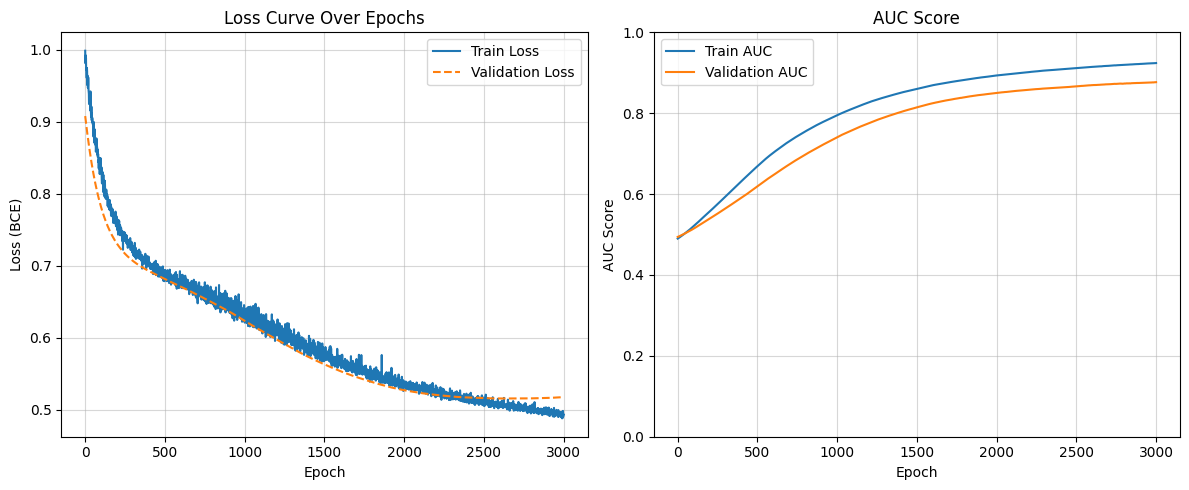

In [31]:
plot_metrics(train_losses, val_losses, val_aucs)

## 5.3. Link prediction for both (institution holds stock symbol) and (fund holds stock symbol)

In [32]:
EPOCHS = 3000
# HIDDEN_CHANNELS = 256
OUT_CHANNELS = 32
LEARNING_RATE = 0.0001

NODE_TYPES = ['company', 'stock_symbol', 'industry', 'sector', 
              'institution', 'fund', 'fund_symbol']

In [33]:
EDGE_TYPES = [
    ('institution', 'holds', 'stock_symbol'),
    ('fund', 'holds', 'stock_symbol'),
]

REV_EDGE_TYPES = [
    ('stock_symbol', 'rev_holds', 'institution'),
    ('stock_symbol', 'rev_holds', 'fund'),
]

EDGE_TYPES_ALL = EDGE_TYPES + REV_EDGE_TYPES

In [34]:
# data split
data = data.to(device)

train_data, val_data, test_data = split_data(data, 
                                             num_val=0.2, 
                                             num_test=0.2, 
                                             neg_sampling_ratio=1.0, 
                                             is_undirected=False, 
                                             edge_types=EDGE_TYPES,
                                             rev_edge_types=REV_EDGE_TYPES,
                                            )

In [35]:
# Prepare the metadata for model initialization
# 1. Extract Shape Information
hake_shapes = {}
fixed_x_shapes = {}
for ntype in data.node_types:
    if hasattr(data[ntype], 'hake_embeds'):
        N, D_hake = data[ntype].hake_embeds.shape
        hake_shapes[ntype] = (N, D_hake)
    if hasattr(data[ntype], 'fixed_x'):
        D_fixed = data[ntype].fixed_x.shape[1]
        fixed_x_shapes[ntype] = D_fixed

# 2. Get the Metadata (contains all node and edge types)
metadata = data.metadata()

In [36]:
# --- 1. Initialize the Feature Manager (Handles trainable HAKE embeddings) ---
# NOTE: The FeatureManager's __init__ method ALREADY loads the HAKE vectors 
# and fixed features into its internal layers and parameters.
feature_manager = FeatureManager(data).to(device)

# --- REMOVE THIS LINE: ---
# feature_manager.load_initial_weights(data) 
# -------------------------

# --- 2. Initialize the GNN Encoder (Homogeneous base model) ---
gnn_encoder = GNNEncoder(OUT_CHANNELS).to(device)

# --- 3. Wrap the GNN Encoder for Heterogeneous processing (The 'Model') ---
# Assuming metadata is defined from data.metadata()
metadata = data.metadata()
hetero_model = to_hetero(gnn_encoder, metadata, aggr='sum').to(device)

# --- 4. Initialize the Decoder ---
predictor = EdgeDecoder().to(device)

# --- 5. Optimizer Setup (CRITICAL: Must include all trainable parameters) ---
optimizer = torch.optim.Adam(
    list(feature_manager.parameters()) + list(hetero_model.parameters()) + list(predictor.parameters()), 
    lr=LEARNING_RATE
)

In [37]:
# training loop
train_losses = []
train_aucs = []
val_losses = []
val_aucs = []

criterion = torch.nn.BCEWithLogitsLoss()
print("\nStarting training loop...")
for epoch in range(1, EPOCHS + 1):
    
    # Train function modified to include the feature_manager
    train_loss = train(
        train_data, 
        feature_manager,  # <-- ADDED
        hetero_model, 
        predictor, 
        optimizer, 
        EDGE_TYPES, 
        criterion, 
        device
    )
    
    # Evaluation function calls modified to include the feature_manager
    _, train_auc = evaluate(
        train_data, 
        feature_manager,  # <-- ADDED
        hetero_model, 
        predictor, 
        EDGE_TYPES, 
        criterion, 
        device
    )
    val_loss, val_auc = evaluate(
        val_data, 
        feature_manager,  # <-- ADDED
        hetero_model, 
        predictor, 
        EDGE_TYPES, 
        criterion, 
        device
    )

    # Log metrics
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch:02d}/{EPOCHS}, Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}, Val Loss: {val_loss:.4f}, Val AUC: {val_auc:.4f}")

# --- Final Testing ---
test_loss, test_auc = evaluate(
    test_data, 
    feature_manager,  # <-- ADDED
    hetero_model, 
    predictor, 
    EDGE_TYPES, 
    criterion, 
    device
)
print(f"\n✅ Training Complete. Test Loss: {test_loss:.4f}, Test AUC: {test_auc:.4f}")


Starting training loop...
Epoch: 10/3000, Train Loss: 2.2863, Train AUC: 0.4964, Val Loss: 2.0812, Val AUC: 0.4997
Epoch: 20/3000, Train Loss: 2.1989, Train AUC: 0.4989, Val Loss: 2.0226, Val AUC: 0.5014
Epoch: 30/3000, Train Loss: 2.1730, Train AUC: 0.5014, Val Loss: 1.9686, Val AUC: 0.5032
Epoch: 40/3000, Train Loss: 2.0990, Train AUC: 0.5040, Val Loss: 1.9190, Val AUC: 0.5050
Epoch: 50/3000, Train Loss: 2.0370, Train AUC: 0.5067, Val Loss: 1.8736, Val AUC: 0.5070
Epoch: 60/3000, Train Loss: 2.0011, Train AUC: 0.5094, Val Loss: 1.8322, Val AUC: 0.5090
Epoch: 70/3000, Train Loss: 1.9395, Train AUC: 0.5123, Val Loss: 1.7944, Val AUC: 0.5111
Epoch: 80/3000, Train Loss: 1.9067, Train AUC: 0.5151, Val Loss: 1.7597, Val AUC: 0.5132
Epoch: 90/3000, Train Loss: 1.8758, Train AUC: 0.5181, Val Loss: 1.7281, Val AUC: 0.5154
Epoch: 100/3000, Train Loss: 1.8355, Train AUC: 0.5211, Val Loss: 1.6994, Val AUC: 0.5177
Epoch: 110/3000, Train Loss: 1.7961, Train AUC: 0.5241, Val Loss: 1.6731, Val AUC:

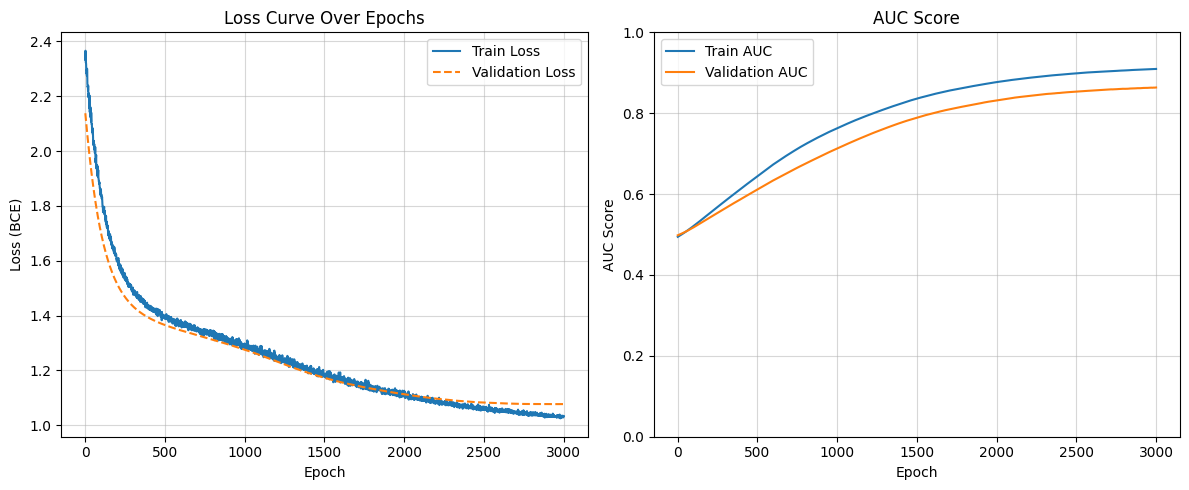

In [38]:
plot_metrics(train_losses, val_losses, val_aucs)